given an audio expressed in time series the objective is to extract pitch, energy, zero crossing rate (ZCR),
Discrete wavelet transform, standard deviation, skewness, kurtosis, mel frequency cepstral coefficents

In [18]:
import librosa
from scipy.signal import butter, filtfilt
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
file = '../EMOVO/f1/dis-f1-n2.wav'
y, sr = librosa.load(file, mono=True)
sr

22050

In [19]:

import scipy.signal as signal

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


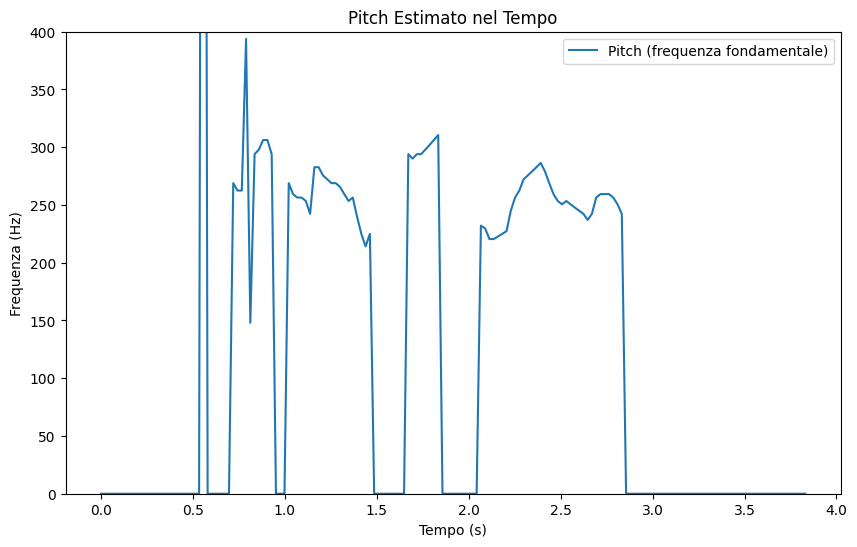

[   0.            0.            0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.            0.
    0.            0.            0.            0.         1696.15384615
    0.            0.            0.            0.            0.
    0.          268.90243902  262.5         262.5         393.75
  147.98657718  294.          297.97297297  306.25        306.25
  294.            0.            0.            0.          268.90243902
  259.41176471  256.39534884  256.39534884  253.44827586  242.30769231
  282.69230769  282.69230769  275.625       272.22222222  268.90243902
  268.90243902  265.6626506   259.41176471  253.44827586  256.39534884
  239.67391304  225.          214.0776699   225.            0.
    0.            0.            0.            0.            0.
    0.            0.          294.          290.13157895  294.
  294.     

In [20]:
def autocorrelation_pitch(y, sr, hop_length=512, fmin=50.0, fmax=2000.0):
    # Definire la dimensione della finestra
    win_length = 2048

    # Estrai l'inviluppo di ampiezza
    amplitude_envelope = np.abs(librosa.stft(y, n_fft=win_length, hop_length=hop_length))

    # Numero di finestre
    n_frames = amplitude_envelope.shape[1]

    # Inizializza l'array dei pitch
    pitches = np.zeros(n_frames)

    for i in range(n_frames):
        # Estrai il frame corrente
        frame = y[i * hop_length:i * hop_length + win_length]
        
        # Calcola l'autocorrelazione del frame
        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(corr)//2:]

        # Trova i picchi nell'autocorrelazione
        d = np.diff(corr)
        start = np.nonzero(d > 0)[0][0]  # Primi campioni non negativi
        
        # Trova il picco massimo nell'intervallo specificato
        peak = np.argmax(corr[start:]) + start
        r = corr[peak]
        
        if r > 0.3:  # Soglia per la selezione del picco (adattabile)
            pitch = sr / peak
            if fmin < pitch < fmax:
                pitches[i] = pitch

    # Calcola i tempi corrispondenti
    times = librosa.frames_to_time(np.arange(n_frames), sr=sr, hop_length=hop_length)

    return pitches, times

# Esempio di utilizzo
pitches, times = autocorrelation_pitch(y, sr)

# Visualizza i primi 10 valori del pitch
print(pitches[:10])

# Visualizzazione del pitch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(times, pitches, label='Pitch (frequenza fondamentale)')
plt.xlabel('Tempo (s)')
plt.ylabel('Frequenza (Hz)')
plt.ylim(0,400)
plt.title('Pitch Estimato nel Tempo')
plt.legend()
plt.show()

print(pitches)
print(len(pitches))

mean_pitch = np.mean(pitches)
std_pitch = np.std(pitches)
print(mean_pitch)
print(std_pitch)

In [21]:
def extract_energy(y):
    Y = np.fft.fft(y)
    P = np.abs(Y)**2
    energy = np.sum(P)/len(P)
    return energy

#we extract the energy
energy = extract_energy(y)
print(energy)


100.18133315021136


ROOT-MEAN-SQUARED-ENERGY

In [22]:
FRAME_SIZE = 256
HOP_SIZE = 128

In [23]:
def rmse(signal, frame_size, hop_length):
    rmse = []
    for i in range(0, len(signal), hop_length): 
        rmse_current_frame = np.sqrt(sum(signal[i:i+frame_size]**2) / frame_size)
        rmse.append(rmse_current_frame)
    return np.array(rmse)  

In [24]:
def amplitude_envelope(signal, frame_size, hop_length):
    return np.array([max(signal[i:i+frame_size]) for i in range(0, len(signal), hop_length)])

In [25]:
rms_y = rmse(y, FRAME_SIZE, HOP_SIZE)
amplitude_y = amplitude_envelope(y, FRAME_SIZE, HOP_SIZE)

In [26]:
frames = range(0, len(rms_y))
t = librosa.frames_to_time(frames, hop_length=HOP_SIZE)

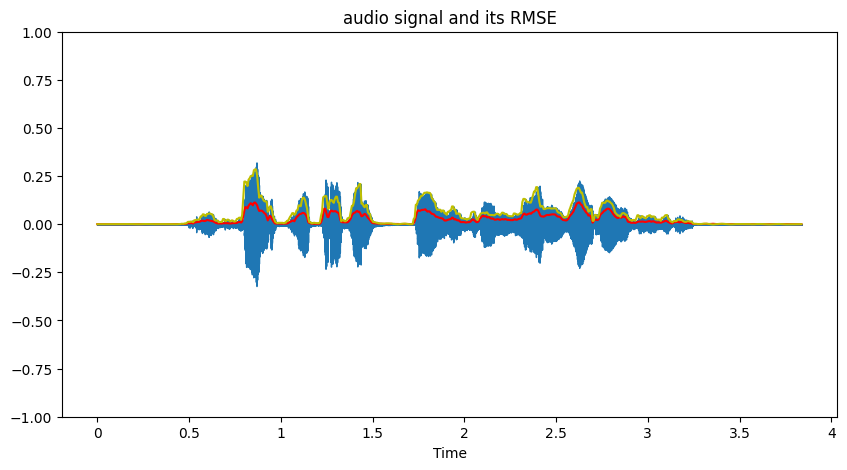

In [27]:
plt.figure(figsize=(10, 5))

librosa.display.waveshow(y)
plt.plot(t, rms_y, color="r")
plt.plot(t, amplitude_y, color="y")
plt.ylim((-1, 1))
plt.title("audio signal and its RMSE")


plt.show()

ZERO-CROSSING-RATE

In [28]:
def extract_zcr(y, frame_size, hop_length):
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=frame_size, hop_length=hop_length)[0]
    return zcr

In [29]:
zcr_y = extract_zcr(y, FRAME_SIZE, HOP_SIZE)
print(zcr_y, len(zcr_y))

[0.         0.0078125  0.015625   0.140625   0.29296875 0.24609375
 0.08984375 0.07421875 0.28125    0.28125    0.078125   0.0078125
 0.16796875 0.21484375 0.11328125 0.09375    0.23828125 0.28125
 0.17578125 0.2109375  0.19921875 0.31640625 0.28515625 0.109375
 0.0859375  0.0703125  0.04296875 0.07421875 0.13671875 0.09375
 0.09765625 0.1796875  0.1015625  0.01953125 0.125      0.1953125
 0.09765625 0.0234375  0.015625   0.         0.         0.015625
 0.05859375 0.04296875 0.         0.         0.         0.0859375
 0.203125   0.31640625 0.3359375  0.171875   0.0390625  0.0546875
 0.0703125  0.10546875 0.1875     0.19921875 0.10546875 0.1640625
 0.15625    0.         0.0078125  0.015625   0.06640625 0.22265625
 0.43359375 0.3984375  0.140625   0.0546875  0.1015625  0.109375
 0.109375   0.1328125  0.078125   0.00390625 0.         0.04296875
 0.04296875 0.         0.046875   0.1015625  0.10546875 0.078125
 0.12890625 0.19921875 0.15625    0.109375   0.08203125 0.0859375
 0.21484375 0.2

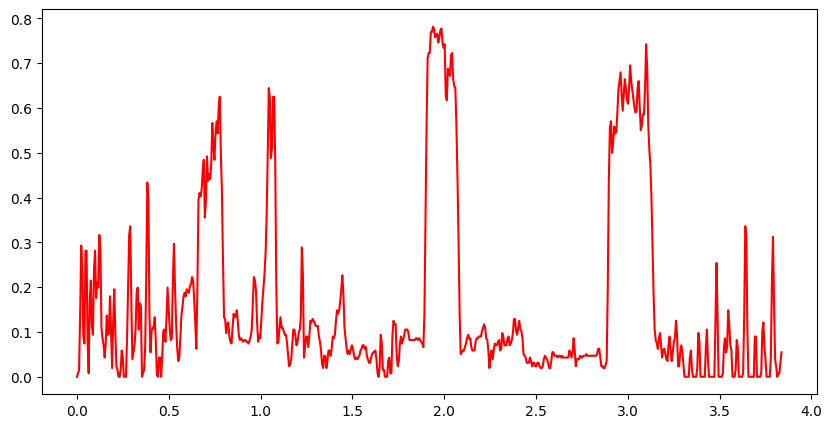

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(t, zcr_y, color="r")

MEL FREQUENCY CEPSTRAL COEFFICENTS

In [31]:
def extract_mfcc(signal, sr=22050, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y = signal, sr=sr, n_mfcc=n_mfcc)
    return mfcc

In [32]:
mfcc_y = extract_mfcc(y)
print(mfcc_y.shape)

(13, 166)
